# Cone-linearized center-disc analysis
**The experiment.** This notebook combines `LinearEquivalentDiscConeLin` with the newer
`LinearEquivalentDisc` implementation. Both show each natural-image center patch three ways:


In [1]:
import contextlib
import io
import sys
import time

if sys.version_info[:2] != (3, 11):
    raise RuntimeError(
        f'This notebook requires the retinanalysis Python 3.11 kernel; '
        f'got Python {sys.version.split()[0]} at {sys.executable}')
import_started = time.perf_counter()

import retinanalysis as ra
import numpy as np
import pandas as pd

from retinanalysis.SCutils import explore as sc
from retinanalysis.SCutils.protocols import linear_equivalent_disc as led

print(f'Python {sys.version.split()[0]} | {sys.executable}')
print(f'Imports ready in {time.perf_counter() - import_started:.2f} s')

Python 3.11.13 | /Users/chrischen/opt/anaconda3/envs/retinanalysis/bin/python
Imports ready in 0.72 s


## 1. Find center-disc experiment dates and cells

Treat `LinearEquivalentDiscConeLin` and the newer, cone-linearizing
`LinearEquivalentDisc` as one center-disc analysis family. Each table row is one available
cell × resolved `onlineAnalysis` × numeric FilterWheel combination, so its values can be copied
directly into Section 2. The table also retains `cell_type_short` and the exact protocol name.
For `LinearEquivalentDisc`, blocks without a saved
`linearizeCones` parameter belong to the older two-stimulus implementation and are excluded
before dates or cells are listed.


In [2]:
CENTER_PROTOCOLS = (
    'LinearEquivalentDiscConeLin',
    'LinearEquivalentDisc',
)
PROTOCOL_LABEL = 'cone-linearized center disc'

protocol_blocks = led.find_blocks(protocols=CENTER_PROTOCOLS, show=False)
with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    protocol_blocks = led.check_series_resistance(
        protocol_blocks, show=False, sample_series_resistance=True)
protocol_cells = (protocol_blocks[[
    'exp_name', 'cell_label', 'cell_type_short', 'onlineAnalysis',
    'filter_wheel_ndf', 'protocol']]
    .drop_duplicates()
    .sort_values(['exp_name', 'cell_label', 'onlineAnalysis',
                  'filter_wheel_ndf', 'protocol'])
    .reset_index(drop=True))
protocol_cells.insert(
    0, 'date_index', pd.factorize(protocol_cells['exp_name'], sort=False)[0] + 1)
print(f'{PROTOCOL_LABEL}: {len(protocol_cells)} available conditions across '
      f'{protocol_cells.exp_name.nunique()} experiments')
sc.scroll_table(protocol_cells, height=420, num_cols=('filter_wheel_ndf',))


cone-linearized center disc: 86 available conditions across 27 experiments


date_index,exp_name,cell_label,cell_type_short,onlineAnalysis,filter_wheel_ndf,protocol
1,2026-03-09_E,Cell1,OFF-parasol,extracellular,0.0,LinearEquivalentDisc
1,2026-03-09_E,Cell3,horizontal,exc,0.0,LinearEquivalentDisc
2,2026-03-10_E,Cell5,horizontal,exc,0.0,LinearEquivalentDisc
3,2026-03-17_E,Cell6,OFF-parasol,extracellular,0.0,LinearEquivalentDisc
4,2026-03-18_E,Cell2,OFF-parasol,extracellular,0.0,LinearEquivalentDisc
5,2026-03-19_E,Cell1,OFF-parasol,extracellular,0.0,LinearEquivalentDisc
5,2026-03-19_E,Cell2,OFF-parasol,extracellular,0.0,LinearEquivalentDisc
5,2026-03-19_E,Cell3,horizontal,exc,0.0,LinearEquivalentDisc
6,2026-04-03_E,Cell1,OFF-parasol,extracellular,0.0,LinearEquivalentDisc
6,2026-04-03_E,Cell4,OFF-parasol,extracellular,0.0,LinearEquivalentDisc


'\n<style>\n.ra-tbl { overflow: auto; }\n.ra-tbl table { border-collapse: collapse; font-size: 12.5px;\n                font-variant-numeric: tabular-nums; }\n.ra-tbl th { position: sticky; top: 0; z-index: 1; text-align: left;\n             font-weight: 600; padding: 4px 12px 4px 0;\n             border-bottom: 1px solid rgba(128,128,128,0.6);\n             background: var(--jp-layout-color0, #fff); }\n.ra-tbl td { padding: 2px 12px 2px 0; vertical-align: top;\n             white-space: nowrap; }\n.ra-tbl tr.grp > td { border-top: 1px solid rgba(128,128,128,0.28); }\n.ra-tbl td.num { text-align: right; }\n.ra-tbl td.lead { font-weight: 600; }\n.ra-tbl summary { cursor: pointer; margin: 2px 0; }\n</style>\n<div class="ra-tbl" style="max-height:420px"><table><thead><tr><th>date_index</th><th>exp_name</th><th>cell_label</th><th>cell_type_short</th><th>onlineAnalysis</th><th>filter_wheel_ndf</th><th>protocol</th></tr></thead><tbody><tr><td>1</td><td>2026-03-09_E</td><td>Cell1</td><td>OFF-

## 2. Analyze one cell condition

This section is standalone after the import cell: enter a `date_index` from Section 1 (or a
previously known index), cell label, resolved `onlineAnalysis`, and numeric FilterWheel value.
It performs its own date lookup and detailed block loading, so Section 1 does not need to be run
first. The first output lists the selected cell label/type, matching block IDs, aperture
diameter, center RF sigma,
stimulus timing, and one row per `imageName`, including its epoch count and
`meanIntensity = maxIntensity × backgroundIntensity`.

Responses use the exact onset window from `preTime` through `preTime + stimTime`: spike count
for extracellular recordings and baseline-subtracted signed area (pA·s) for whole-cell
recordings. Each scatter point is one `(imageName, patchIndex)` pair; x and y error bars are
SEM across repeat epochs. The per-image and pooled figures show image vs standard disc in grey
and image vs cone-linearized disc in red, with a unity line. Patch indices that restart in a new
image remain separate. The final figure uses empirical NLI CDFs and a second panel with
the mean ± SEM across every image-specific patch for this cell. After Section 2a has saved this
exact block set once, rerunning after a kernel restart reloads those patch results instead of
re-reading traces and detecting spikes. Pass `reuse_saved=False` to `analyze_condition` when a
deliberate raw-data recomputation is needed. The final sanity-check panel shows a few
response-selected `(imageName, patchIndex)` examples: trial-normalized PSTHs for
extracellular recordings, or baseline-subtracted mean traces for `exc`/`inh`.

2026-08-18_G_2/Cell9 (OFF-midget) | extracellular | FilterWheel 1
block_ids: 37704, 37702, 37703
3 imageNames | 154 epochs


imageName,block_ids,epochs,maxIntensity,backgroundIntensity,meanIntensity
00152,[37704],55,7600.0,0.19940717249552456,1515.4945109659866
03758,[37702],59,7600.0,0.14730007774911566,1119.480590893279
03760,[37703],40,7600.0,0.1758734173548828,1336.6379718971093


Key protocol parameters:
 apertureDiameter  rfSigmaCenter  preTime  stimTime  tailTime
            120.0           30.0    200.0     200.0     200.0
analyzed 3 blocks, 154 epochs, 30 image/patch pairs


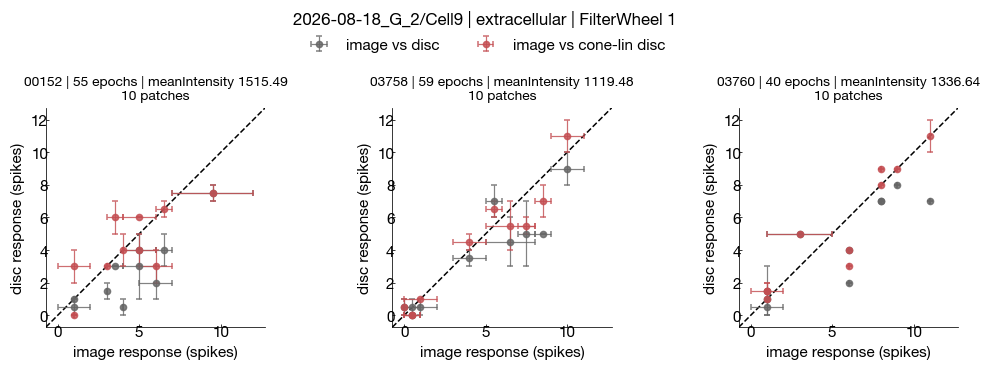

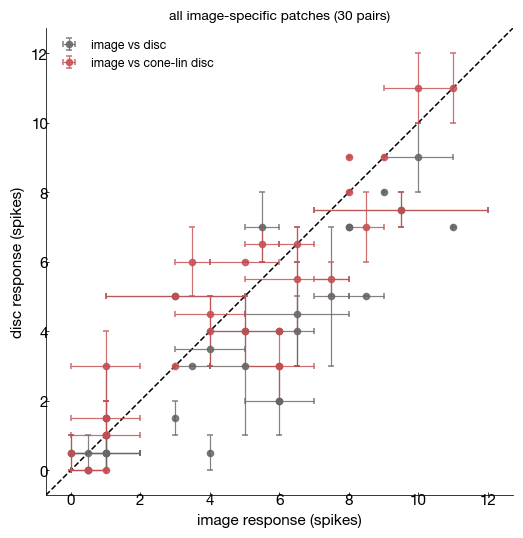

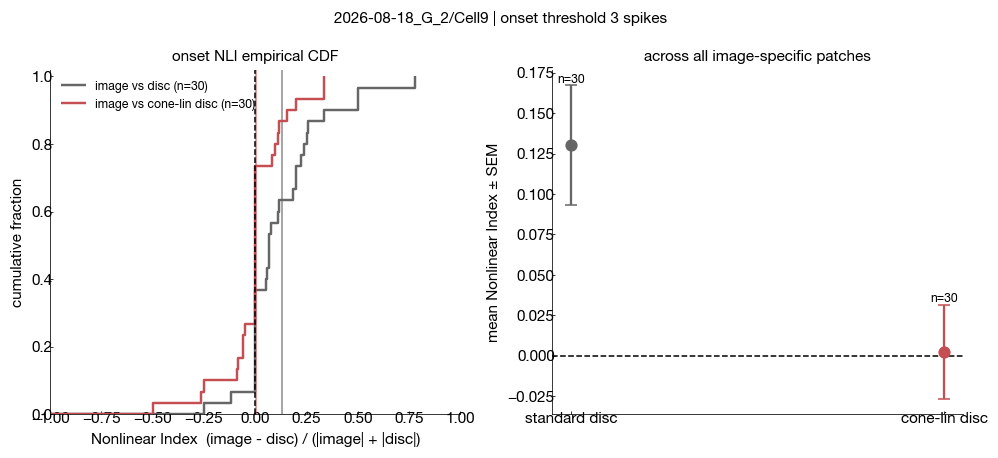

In [29]:
# Standalone after the imports; Section 1 is optional.
CENTER_PROTOCOLS = (
    'LinearEquivalentDiscConeLin',
    'LinearEquivalentDisc',
)
PROTOCOL_LABEL = 'cone-linearized center disc'
DATE_INDEX = 27
CELL_LABEL = 'Cell9'
ONLINE_ANALYSIS = 'extracellular'  # 'extracellular', 'exc', or 'inh'
FILTER_WHEEL_VALUE = 1.0          # authoritative numeric FilterWheel value

analysis_dates = led.find_protocol_cells(CENTER_PROTOCOLS, show=False)
analysis_dates.insert(
    0, 'date_index', pd.factorize(analysis_dates['exp_name'], sort=False)[0] + 1)
date_rows = analysis_dates.loc[analysis_dates.date_index.eq(DATE_INDEX)]
if date_rows.empty:
    raise ValueError(f'date_index {DATE_INDEX} is not available for {PROTOCOL_LABEL}')
EXP_NAME = date_rows.exp_name.iloc[0]

df_blocks = led.find_blocks(
    exp_names=[EXP_NAME], protocols=CENTER_PROTOCOLS, show=False)
with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    df_blocks = led.check_series_resistance(
        df_blocks, show=False, sample_series_resistance=True)
selected_blocks = df_blocks.copy()
if selected_blocks.empty:
    raise ValueError(f'{EXP_NAME!r} has no cone-linearized center-disc blocks')

condition_blocks = led.select_condition_blocks(
    selected_blocks, CELL_LABEL, ONLINE_ANALYSIS, FILTER_WHEEL_VALUE)
key_parameters = (condition_blocks[[
    'apertureDiameter', 'rfSigmaCenter', 'preTime', 'stimTime', 'tailTime']]
    .drop_duplicates().reset_index(drop=True))
print('Key protocol parameters:')
print(key_parameters.to_string(index=False))
condition = led.analyze_condition(condition_blocks)
image_fig, pooled_fig, nli_fig = led.plot_condition(condition)
#sample_psth_fig = led.plot_condition_sample_psths(
#    condition_blocks, condition, n_pairs=3)

### 2a. Save this cell for population analysis

Save one compressed HDF5 record for the selected cell condition, similar to a MATLAB struct
containing arrays. Cell metadata is stored once, and the image summary and patch responses are
kept as typed arrays instead of tens of thousands of CSV rows. `condition_population_table()`
still expands the selected condition for display when needed. Each distinct date/cell/mode/FW
condition gets its own file. Before saving, the code checks all routed and legacy outputs for
the same date/cell/mode/site/FW condition, prints an alert, replaces the canonical record, and
removes duplicate copies. The file also becomes the fast restart source for Section 2 when the selected
block IDs match. Later,
`led.load_condition_outputs()` combines every saved cell into one population table.

In [27]:
condition_output_path = led.save_condition_output(condition, remove_duplicates=True)
population_ready = led.condition_population_table(condition)
sc.scroll_table(
    population_ready, height=360,
    num_cols=('filter_wheel_ndf', 'patchIndex', 'maxIntensity',
              'meanIntensity', 'image_response', 'disc_response',
              'cone_disc_response', 'nli_image_vs_disc',
              'nli_image_vs_cone_disc'));

No existing saved copy found for 2026-08-18_G_2/Cell10 (extracellular, center, FW0).
saved 1 condition (20 patches as arrays) to /Volumes/ChrisNewSSD/retinanalysis_output/linear_equivalent_disc/condition_outputs/center_disc/2026-08-18_G_2__Cell10__extracellular__center__LinearEquivalentDiscConeLin__FW0.h5


date,cell_label,cell_type,onlineAnalysis,protocol,site,filter_wheel_ndf,imageName,patchIndex,patch_key,block_ids,image_epochs,maxIntensity,backgroundIntensity,meanIntensity,response_units,image_response,image_response_sem,image_trials,disc_response,disc_response_sem,disc_trials,cone_disc_response,cone_disc_response_sem,cone_disc_trials,nli_image_vs_disc,nli_image_vs_cone_disc,output_version
2026-08-18_G_2,Cell10,OFF-midget,extracellular,LinearEquivalentDiscConeLin,center,0.0,01829,1.0,01829:1,37727,60,77000.0,0.15686291769365707,12078.444662411594,spikes,8.0,0.0,2,7.5,0.5,2,8.0,0.0,2,0.03225806451612903,0.0,1
2026-08-18_G_2,Cell10,OFF-midget,extracellular,LinearEquivalentDiscConeLin,center,0.0,01829,2.0,01829:2,37727,60,77000.0,0.15686291769365707,12078.444662411594,spikes,5.5,0.5,2,5.5,1.4999999999999998,2,10.0,2.9999999999999996,2,0.0,-0.2903225806451613,1
2026-08-18_G_2,Cell10,OFF-midget,extracellular,LinearEquivalentDiscConeLin,center,0.0,01829,3.0,01829:3,37727,60,77000.0,0.15686291769365707,12078.444662411594,spikes,13.0,2.9999999999999996,2,10.0,4.0,2,11.0,2.9999999999999996,2,0.13043478260869565,0.08333333333333333,1
2026-08-18_G_2,Cell10,OFF-midget,extracellular,LinearEquivalentDiscConeLin,center,0.0,01829,4.0,01829:4,37727,60,77000.0,0.15686291769365707,12078.444662411594,spikes,12.5,4.5,2,6.0,5.999999999999999,2,15.0,4.0,2,0.35135135135135137,-0.09090909090909091,1
2026-08-18_G_2,Cell10,OFF-midget,extracellular,LinearEquivalentDiscConeLin,center,0.0,01829,5.0,01829:5,37727,60,77000.0,0.15686291769365707,12078.444662411594,spikes,5.0,5.0,2,6.0,5.999999999999999,2,5.5,5.499999999999999,2,-0.09090909090909091,-0.047619047619047616,1
2026-08-18_G_2,Cell10,OFF-midget,extracellular,LinearEquivalentDiscConeLin,center,0.0,01829,6.0,01829:6,37727,60,77000.0,0.15686291769365707,12078.444662411594,spikes,8.0,8.0,2,5.0,5.0,2,7.5,6.499999999999999,2,0.23076923076923078,0.03225806451612903,1
2026-08-18_G_2,Cell10,OFF-midget,extracellular,LinearEquivalentDiscConeLin,center,0.0,01829,7.0,01829:7,37727,60,77000.0,0.15686291769365707,12078.444662411594,spikes,8.5,8.499999999999998,2,1.5,1.4999999999999998,2,5.5,5.499999999999999,2,0.7,0.21428571428571427,1
2026-08-18_G_2,Cell10,OFF-midget,extracellular,LinearEquivalentDiscConeLin,center,0.0,01829,8.0,01829:8,37727,60,77000.0,0.15686291769365707,12078.444662411594,spikes,1.5,1.4999999999999998,2,1.5,1.4999999999999998,2,3.0,2.9999999999999996,2,0.0,-0.3333333333333333,1
2026-08-18_G_2,Cell10,OFF-midget,extracellular,LinearEquivalentDiscConeLin,center,0.0,01829,9.0,01829:9,37727,60,77000.0,0.15686291769365707,12078.444662411594,spikes,4.5,4.5,2,6.0,2.9999999999999996,2,5.5,5.499999999999999,2,-0.14285714285714285,-0.1,1
2026-08-18_G_2,Cell10,OFF-midget,extracellular,LinearEquivalentDiscConeLin,center,0.0,01829,10.0,01829:10,37727,60,77000.0,0.15686291769365707,12078.444662411594,spikes,19.0,2.0,2,15.0,4.0,2,19.5,3.4999999999999996,2,0.11764705882352941,-0.012987012987012988,1


### 2b. Check saved cells

Read only the small metadata attributes from saved center-disc conditions—without loading the
patch arrays—and list date, cell label/type, resolved `onlineAnalysis`, and FilterWheel value.

In [3]:
saved_cells = led.load_condition_index(protocol=CENTER_PROTOCOLS)
print(f'{len(saved_cells)} saved cell condition(s)')
sc.scroll_table(saved_cells, height=300, num_cols=('filter_wheel_ndf',));

15 saved cell condition(s)


date,cell_label,cell_type,onlineAnalysis,filter_wheel_ndf
2026-03-09_E,Cell1,OFF-parasol,extracellular,0.0
2026-03-18_E,Cell2,OFF-parasol,extracellular,0.0
2026-03-19_E,Cell1,OFF-parasol,extracellular,0.0
2026-03-19_E,Cell2,OFF-parasol,extracellular,0.0
2026-04-03_E,Cell1,OFF-parasol,extracellular,0.0
2026-04-03_E,Cell4,OFF-parasol,extracellular,0.0
2026-04-14_E,Cell1,OFF-parasol,extracellular,0.0
2026-04-14_E,Cell1,OFF-parasol,extracellular,1.0
2026-04-15_E,Cell5,OFF-parasol,extracellular,0.0
2026-04-15_E,Cell5,OFF-parasol,extracellular,1.0


## 3. Population by image and cell type

Load saved HDF5 conditions from either center-disc protocol name. Each row is one cell ×
FilterWheel × `imageName`: `meanIntensity` is x, and the two y values are mean patch NLI for
the ordinary and cone-linearized disc comparisons. Then group rows into `[500, 1500)`,
`[1500, 3500)`, `[3500, 6000)`, and `[6000, 20000]` within each cell type and plot population
mean NLI ± SEM. No averaging occurs across cells before this grouping. If old saved metadata
contains multiple comma-separated intensity values for one FilterWheel condition, the temporary
loader correction warns and uses the larger value (for example, `1199.85, 11998.5` becomes
`11998.5`).


/Users/chrischen/Documents/GitHub/retinanalysis/src/retinanalysis/SCutils/protocols/linear_equivalent_disc.py:1472: RuntimeWarning: /Volumes/ChrisNewSSD/retinanalysis_output/linear_equivalent_disc/condition_outputs/center_disc/2026-06-04_G__Cell2__extracellular__center__LinearEquivalentDiscConeLin__FW0.h5: imageName 01769: conflicting saved intensity metadata; using larger value (maxIntensity='7700, 77000' -> 77000; meanIntensity='1199.85, 11998.5' -> 11998.5)
  image_summary = _normalize_saved_condition_intensities(
/Users/chrischen/Documents/GitHub/retinanalysis/src/retinanalysis/SCutils/protocols/linear_equivalent_disc.py:1472: RuntimeWarning: /Volumes/ChrisNewSSD/retinanalysis_output/linear_equivalent_disc/condition_outputs/center_disc/2026-06-04_G__Cell3__extracellular__center__LinearEquivalentDiscConeLin__FW1.h5: imageName 03758: conflicting saved intensity metadata; using larger value (maxIntensity='7600, 7700' -> 7700; meanIntensity='1119.48, 1134.21' -> 1134.21)
  image_summar

102 cell/image rows from 25 cells


exp_name,cell_label,cell_type,onlineAnalysis,protocol,filter_wheel_ndf,imageName,meanIntensity,n_patches,mean_nli_disc,mean_nli_cone_disc
2026-08-12_G,Cell2,OFF-midget,extracellular,LinearEquivalentDiscConeLin,0.0,02999,8860.540918026654,10,0.07328734209053359,-0.038740616553884985
2026-08-12_G,Cell2,OFF-midget,extracellular,LinearEquivalentDiscConeLin,0.0,03347,10111.988640660436,10,0.16185785683995754,-0.20698816628807518
2026-08-12_G,Cell2,OFF-midget,extracellular,LinearEquivalentDiscConeLin,0.0,02733,10707.252038846631,10,0.24005756986997998,-0.21503916177505905
2026-08-12_G,Cell2,OFF-midget,extracellular,LinearEquivalentDiscConeLin,0.0,03758,11342.105986681905,10,0.13412825085058558,-0.10100494400275681
2026-08-12_G,Cell2,OFF-midget,extracellular,LinearEquivalentDiscConeLin,0.0,01192,11472.21978935895,10,0.15638925794970845,-0.04591151368086353
2026-08-12_G,Cell2,OFF-midget,extracellular,LinearEquivalentDiscConeLin,0.0,01769,11998.47075153831,10,0.19787063398599772,-0.0002650934485374956
2026-08-12_G,Cell2,OFF-midget,extracellular,LinearEquivalentDiscConeLin,0.0,01829,12078.444662411594,10,0.19849451083950115,-0.014146987168054584
2026-08-12_G,Cell2,OFF-midget,extracellular,LinearEquivalentDiscConeLin,0.0,03760,13542.253136325975,10,0.17572685200767393,-0.005758656390235347
2026-08-12_G,Cell2,OFF-midget,extracellular,LinearEquivalentDiscConeLin,0.0,00152,15354.35228215539,10,0.24434143863794394,-0.22271452878351344
2026-08-12_G,Cell2,OFF-midget,extracellular,LinearEquivalentDiscConeLin,0.0,03093,15523.484008544512,10,0.14680920845094686,-0.07849915091294402


101 of 102 rows are within 500–20000


cell_type,light_level,light_min,light_max,meanIntensity,n_cells,n_cell_images,mean_nli_disc,sem_nli_disc,mean_nli_cone_disc,sem_nli_cone_disc
OFF-midget,500-1500,500.0,1500.0,1164.1584712256006,1,7,0.08676562634260665,0.023448396685479878,0.010126514763353786,0.00938172804225336
OFF-midget,1500-3500,1500.0,3500.0,1523.841271489086,1,2,0.221756906243825,0.03621409825943761,-0.013174367048274405,0.05289902051139929
OFF-midget,6000-20000,6000.0,20000.0,11936.675910479715,3,17,0.2041575353849371,0.017554956937285333,-0.12167004118620472,0.026516326104999276
OFF-parasol,500-1500,500.0,1500.0,992.147572891004,9,20,0.28435377937915407,0.034122578730108995,0.08019669922860534,0.02696280473202607
OFF-parasol,1500-3500,1500.0,3500.0,1525.4648695907629,2,2,0.299284247987163,0.007963688645542477,-0.17863539560438108,0.03589770118325249
OFF-parasol,3500-6000,3500.0,6000.0,5010.193100109121,11,22,0.23694582217975063,0.029484259210159992,0.009974589159019965,0.029935641075220017
OFF-parasol,6000-20000,6000.0,20000.0,11548.26635524263,6,20,0.5583348286975103,0.036652478002914636,-0.09687703106257026,0.02557821222455183
ON-parasol,1500-3500,1500.0,3500.0,3452.158799231536,1,1,-0.06358729380363436,,0.16189596400239362,
ON-parasol,3500-6000,3500.0,6000.0,4541.359902824585,5,10,-0.11539275224132486,0.048542994692848514,0.40479284734443066,0.07308249801234896


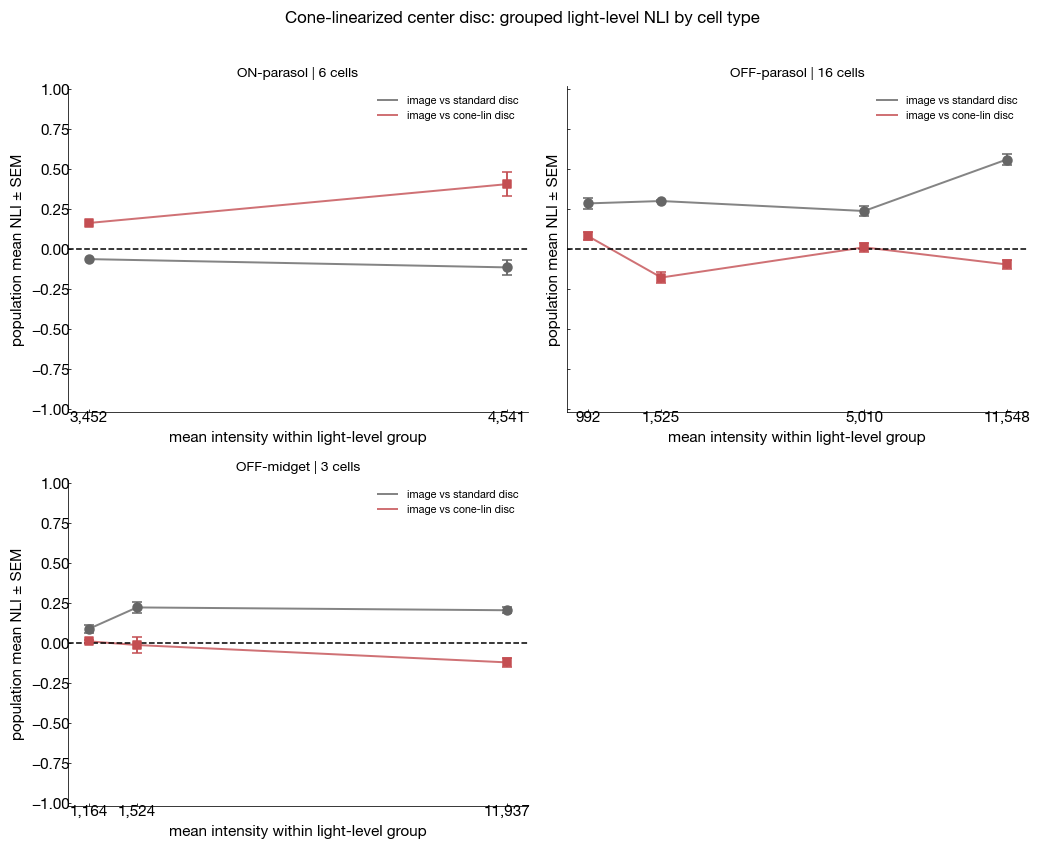

In [9]:
image_nli = led.load_condition_image_nli_summary(
    protocol=CENTER_PROTOCOLS)
print(f'{len(image_nli)} cell/image rows from {image_nli.cell_id.nunique()} cells')
image_nli_view = image_nli[[
    'exp_name', 'cell_label', 'cell_type', 'onlineAnalysis', 'protocol',
    'filter_wheel_ndf', 'imageName', 'meanIntensity', 'n_patches',
    'mean_nli_disc', 'mean_nli_cone_disc']]
sc.scroll_table(
    image_nli_view, height=360,
    num_cols=('filter_wheel_ndf', 'meanIntensity', 'n_patches',
              'mean_nli_disc', 'mean_nli_cone_disc'))
light_level_nli = led.summarize_image_nli_light_levels(image_nli)
print(f'{light_level_nli.n_cell_images.sum()} of {len(image_nli)} rows are within 500–20000')
sc.scroll_table(
    light_level_nli, height=300,
    num_cols=('light_min', 'light_max', 'meanIntensity', 'n_cells',
              'n_cell_images', 'mean_nli_disc', 'sem_nli_disc',
              'mean_nli_cone_disc', 'sem_nli_cone_disc'))
led.plot_image_nli_by_cell_type(
    image_nli, title_prefix='Cone-linearized center disc');


### 3a. Pooled patch NLI distributions

Pool every patch NLI from saved center-disc HDF5 conditions, without averaging by image or cell.
The first figure compares ordinary and cone-linearized discs across all saved patches. The second
repeats the normalized 50-bin density and empirical CDF separately for each cell type.


10 standard and 10 cone-lin patch NLIs from 20 saved rows and 1 cells


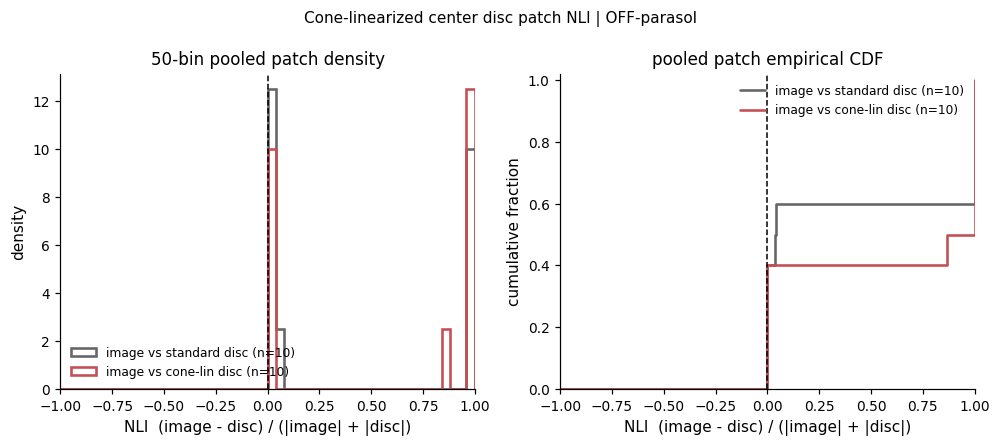

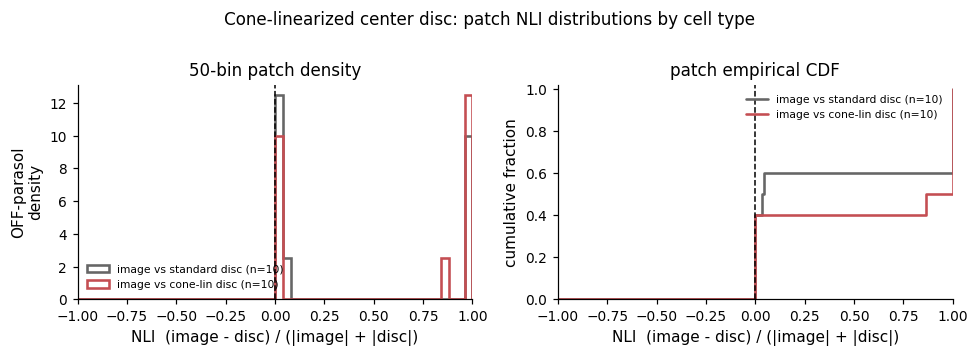

In [9]:
patch_nli = led.load_condition_patch_nli(
    protocol=CENTER_PROTOCOLS)
finite_patch_nli = np.isfinite(
    patch_nli[['nli_disc', 'nli_cone_disc']]).sum()
print(f"{finite_patch_nli['nli_disc']} standard and "
      f"{finite_patch_nli['nli_cone_disc']} cone-lin patch NLIs from "
      f'{len(patch_nli)} saved rows and {patch_nli.cell_id.nunique()} cells')
led.plot_pooled_patch_nli_distributions(
    patch_nli, bins=50, title_prefix='Cone-linearized center disc');
led.plot_patch_nli_distributions_by_cell_type(
    patch_nli, bins=50, title_prefix='Cone-linearized center disc');


### 3b. Cell-level averages by light level and paired high-light comparison

For each cell, pool all patches across all `imageName`s within `[500, 1500)` (~1k) or
`[6000, 20000]` (~10k), then calculate one ordinary-disc and one cone-linearized mean NLI.
Faint points are those cell means; large points and error bars are population mean ± SEM
across cells, so a cell with more patches does not get extra population weight. Finally, for
each cell type, the paired plot pools every patch at 7000 R* and above into one ordinary-disc
mean and one cone-linearized-disc mean per cell, then joins those two values with a line.


cell_type,cell_id,exp_name,cell_label,light_level,light_min,light_max,meanIntensity,n_images,n_patches,mean_nli_disc,mean_nli_cone_disc
OFF-midget,2026-08-12_G/Cell2,2026-08-12_G,Cell2,~1k,500.0,1500.0,1164.1584712256004,7,70,0.08676562634260665,0.010126514763353784
OFF-midget,2026-08-12_G/Cell2,2026-08-12_G,Cell2,~10k,6000.0,20000.0,12099.111221455036,10,100,0.1728962921522829,-0.09290688190039244
OFF-midget,2026-08-18_G/Cell3,2026-08-18_G,Cell3,~10k,6000.0,20000.0,11702.365522902259,5,50,0.2508644884449683,-0.22539003667312887
OFF-midget,2026-08-18_G_2/Cell10,2026-08-18_G_2,Cell10,~10k,6000.0,20000.0,11710.27532454675,2,20,0.24369636889813032,-0.006185848897955637
OFF-parasol,2026-04-14_E/Cell1,2026-04-14_E,Cell1,~1k,500.0,1500.0,527.6202520645243,1,30,0.06493342054244963,-0.08807592632290874
OFF-parasol,2026-04-15_E/Cell5,2026-04-15_E,Cell5,~1k,500.0,1500.0,572.5057596936884,2,60,0.17698554042911005,0.07967447205179684
OFF-parasol,2026-04-17_E/Cell2,2026-04-17_E,Cell2,~1k,500.0,1500.0,546.7900019009631,1,30,0.21995669585380717,0.2082289158305154
OFF-parasol,2026-05-06_E/Cell1,2026-05-06_E,Cell1,~1k,500.0,1500.0,546.7900019009631,1,30,0.1900737187928016,0.14333284820262093
OFF-parasol,2026-06-02_G/Cell5,2026-06-02_G,Cell5,~1k,500.0,1500.0,1119.480590893279,1,20,0.41510180977451905,-0.039285554661372034
OFF-parasol,2026-06-04_G/Cell2,2026-06-04_G,Cell2,~1k,500.0,1500.0,1159.4507275804199,2,80,0.40722734180995246,0.1668467624411112


cell_type,cell_id,exp_name,cell_label,min_intensity,meanIntensity,n_images,n_patches,mean_nli_disc,mean_nli_cone_disc
OFF-midget,2026-08-12_G/Cell2,2026-08-12_G,Cell2,7000.0,12099.111221455036,10,100,0.1728962921522829,-0.09290688190039244
OFF-midget,2026-08-18_G/Cell3,2026-08-18_G,Cell3,7000.0,11702.365522902259,5,50,0.2508644884449683,-0.22539003667312887
OFF-midget,2026-08-18_G_2/Cell10,2026-08-18_G_2,Cell10,7000.0,11710.27532454675,2,20,0.24369636889813032,-0.006185848897955637
OFF-parasol,2026-04-24_E/Cell4,2026-04-24_E,Cell4,7000.0,8044.318206118542,1,30,0.2712556696795002,0.14358846858919583
OFF-parasol,2026-06-02_G/Cell5,2026-06-02_G,Cell5,7000.0,11734.466608177183,4,80,0.3973643280053918,-0.2286965462952743
OFF-parasol,2026-06-04_G/Cell2,2026-06-04_G,Cell2,7000.0,11594.51458791962,2,80,0.6381496343602917,-0.029514574802736414
OFF-parasol,2026-06-04_G/Cell3,2026-06-04_G,Cell3,7000.0,11518.726182498289,2,40,0.400482303182861,-0.17840282425494677
OFF-parasol,2026-06-04_G/Cell4,2026-06-04_G,Cell4,7000.0,11342.105986681905,1,40,0.5689951831123979,-0.16075332327390612
OFF-parasol,2026-08-18_G/Cell4,2026-08-18_G,Cell4,7000.0,11983.34568228378,7,70,0.6877757260310647,-0.05285318719869321


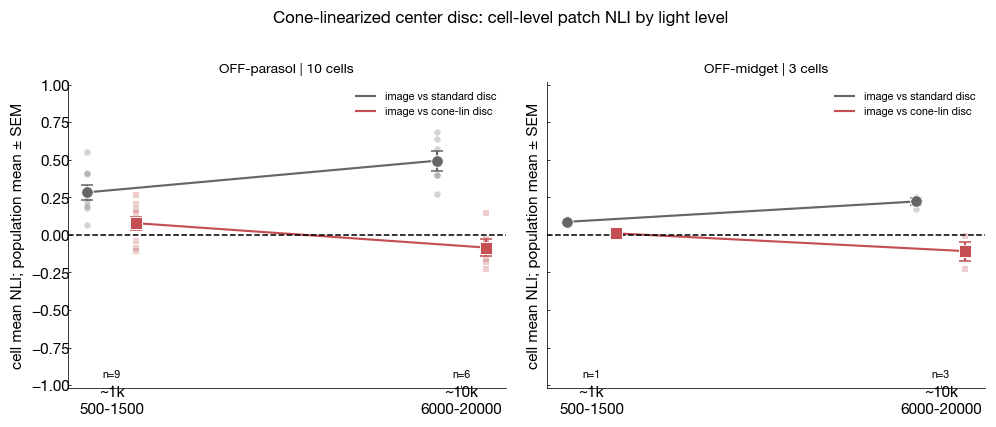

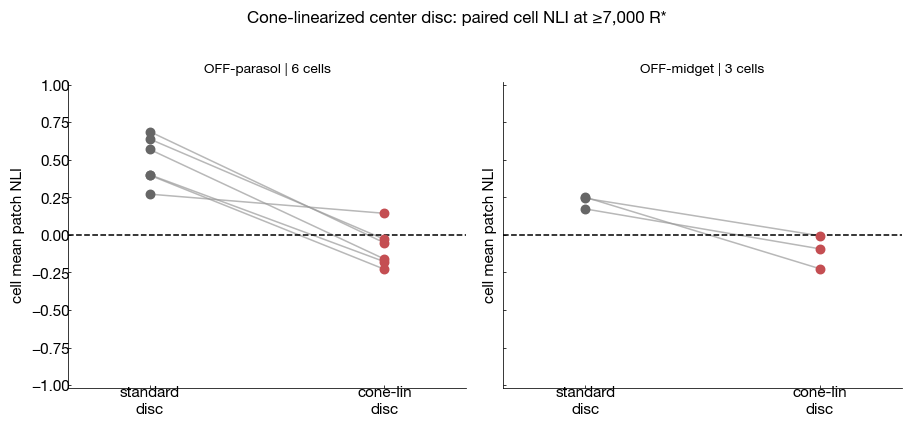

In [10]:
cell_light_nli = led.summarize_cell_patch_nli_light_levels(patch_nli)
sc.scroll_table(
    cell_light_nli, height=320,
    num_cols=('light_min', 'light_max', 'meanIntensity', 'n_images',
              'n_patches', 'mean_nli_disc', 'mean_nli_cone_disc'))
led.plot_cell_patch_nli_by_light(
    cell_light_nli, title_prefix='Cone-linearized center disc');
high_light_cell_nli = led.summarize_cell_patch_nli_above(
    patch_nli, min_intensity=7000)
sc.scroll_table(
    high_light_cell_nli, height=300,
    num_cols=('min_intensity', 'meanIntensity', 'n_images', 'n_patches',
              'mean_nli_disc', 'mean_nli_cone_disc'))
led.plot_cell_patch_nli_paired_above(
    high_light_cell_nli, min_intensity=7000,
    title_prefix='Cone-linearized center disc');


### 3c. Export MATLAB population files by cell type

Write one `*LinEquivCenterDisc.mat` file per cell type using the same `collectedResults` cell-array
and nested `results` struct layout as `OffParasolLinEquiv.mat`. Each cell-array element is one
unique date/cell × FilterWheel (`nd`) × `imageID` condition. The original 13 fields are retained,
with scalar `maxIntensity` and `meanIntensity` appended. Because the reference schema has no
recording-mode field, this export explicitly uses extracellular conditions only. Any old
comma-separated intensity metadata is corrected to the larger value before export and printed
below for manual review. Files are written under the center-disc condition output folder. The
final table counts exported condition entries, unique cells, and experiment dates from rig E
(`fred_data`) and rig G (`chris_data`), both overall and within each cell type.


In [ ]:
matlab_exports = led.export_center_disc_population_mat_files(
    online_analysis='extracellular')
pd.DataFrame([
    {'cell_type': cell_type, 'file': str(path)}
    for cell_type, path in matlab_exports.items()
])
rig_summary = led.summarize_matlab_export_rigs(matlab_exports)
sc.scroll_table(
    rig_summary, height=300,
    num_cols=('condition_entries', 'unique_cells', 'experiment_dates'))

### 3d. Build the all-FilterWheel physical-patch population table (temporary)

This bridge starts from all saved center-disc population conditions and retains the numeric
FilterWheel value on every row so light settings can be separated later during analysis.
It reopens the original epoch metadata named by each saved HDF5 file, then uses the recorded
full protocol name and `currentStimSet` to load the matching NaturalImageFlash `.mat` library.
Each protocol-local `patchIndex` is translated to a stable physical-patch ID made from
`(stimulus library, imageName, x location, y location)`. The old index remains as provenance,
but is not treated as globally unique.

The consolidated HDF5 contains cell identity, responses and both NLIs, FilterWheel,
`maxIntensity`, original normalized image mean (`imageMeanIntensity`, `[0,1]`), calibrated
mean (`meanIntensity_Rstar_per_s`), both equivalent intensities, patch contrast mean, patch
mean intensity and variance, raw sampling settings, and the physical
patch identity. `delta_nli_cone_minus_disc` is included for the planned variance analysis.
For older `LinearEquivalentDisc` blocks, the protocol displayed the correct cone-equivalent
disc but accidentally saved the ordinary equivalent intensity under both parameter names.
The table therefore reconstructs both displayed intensities with the recorded protocol formula,
retains the original values in `*_recorded_values`, and marks corrected rows explicitly.
The build stops rather than mixing records if an already-saved `(imageName, patchIndex)` maps
to more than one physical location. Incomplete image/disc/cone-disc response triplets are
excluded from the analysis-ready `patch_population` group and retained in the same file under
`excluded_qc`. Image paths, image and stimulus-set names, patch x/y locations,
canvas geometry, aperture, RF, Weber, sampling and protocol metadata are retained so each patch
can be reconstructed and visualized later.


In [ ]:
patch_variance_population, excluded_patch_qc = (
    led.build_center_disc_patch_variance_population(return_qc=True))
patch_variance_output = led.save_patch_variance_population(
    patch_variance_population, excluded_qc=excluded_patch_qc)
print(f'{patch_variance_population.patch_uid.nunique()} unique physical patches; ' 
      f'{len(patch_variance_population)} cell-patch rows')
print(f'{len(excluded_patch_qc)} excluded patch rows retained for QC')
print(f'Saved: {patch_variance_output}')
patch_variance_view = patch_variance_population[[
    'date', 'cell_label', 'cell_type', 'onlineAnalysis',
    'filter_wheel_ndf', 'imageName', 'patch_uid',
    'maxIntensity', 'imageMeanIntensity', 'meanIntensity_Rstar_per_s',
    'patchMeanContrast', 'patchMeanIntensity', 'patchVariance',
    'equivalentIntensity', 'equivalentIntensityConeLin',
    'cone_equivalent_metadata_corrected',
    'image_response', 'disc_response', 'cone_disc_response',
    'nli_image_vs_disc', 'nli_image_vs_cone_disc',
    'delta_nli_cone_minus_disc']]
sc.scroll_table(
    patch_variance_view, height=420,
    num_cols=('filter_wheel_ndf', 'maxIntensity', 'imageMeanIntensity',
              'meanIntensity_Rstar_per_s', 'patchMeanContrast',
              'patchMeanIntensity', 'patchVariance',
              'equivalentIntensity', 'equivalentIntensityConeLin',
              'image_response', 'disc_response', 'cone_disc_response',
              'nli_image_vs_disc', 'nli_image_vs_cone_disc',
              'delta_nli_cone_minus_disc'))

#### 3d.1. Load and inspect the saved table without rebuilding

Run this cell after imports to reload the consolidated all-FilterWheel HDF5 directly. It does
not reopen raw recordings, reconstruct patches, or rerun Section 3d. Both the analysis-ready
population and the excluded QC rows are available for inspection.

In [9]:
patch_variance_output = led.patch_variance_population_path()
patch_variance_population = led.load_patch_variance_population(
    patch_variance_output)
excluded_patch_qc = led.load_patch_variance_population(
    patch_variance_output, excluded_qc=True)
print(f'Loaded {len(patch_variance_population)} analysis-ready rows and '
      f'{len(excluded_patch_qc)} excluded QC rows from:')
print(patch_variance_output)

patch_variance_inspect_columns = [
    'date', 'cell_label', 'cell_type', 'onlineAnalysis',
    'filter_wheel_ndf', 'imageName', 'patch_uid', 'patch_x_vh', 'patch_y_vh',
    'meanIntensity_Rstar_per_s', 'patchMeanContrast', 'patchVariance',
    'nli_image_vs_disc', 'nli_image_vs_cone_disc',
    'delta_nli_cone_minus_disc']
sc.scroll_table(
    patch_variance_population[patch_variance_inspect_columns],
    height=480,
    num_cols=('filter_wheel_ndf', 'patch_x_vh', 'patch_y_vh',
              'meanIntensity_Rstar_per_s', 'patchMeanContrast',
              'patchVariance', 'nli_image_vs_disc',
              'nli_image_vs_cone_disc', 'delta_nli_cone_minus_disc'))

Loaded 1895 analysis-ready rows and 94 excluded QC rows from:
/Volumes/ChrisNewSSD/retinanalysis_output/linear_equivalent_disc/population/center_disc_patch_variance_allFW.h5


date,cell_label,cell_type,onlineAnalysis,filter_wheel_ndf,imageName,patch_uid,patch_x_vh,patch_y_vh,meanIntensity_Rstar_per_s,patchMeanContrast,patchVariance,nli_image_vs_disc,nli_image_vs_cone_disc,delta_nli_cone_minus_disc
2026-03-18_E,Cell2,OFF-parasol,extracellular,0.0,01151,NaturalImageFlashLibrary_120117:imk01151:x200:y369,200.0,369.0,4556.583349174693,-0.3499426857873377,0.08128027522399756,0.014084507042253521,0.0,-0.014084507042253521
2026-03-18_E,Cell2,OFF-parasol,extracellular,0.0,01151,NaturalImageFlashLibrary_120117:imk01151:x359:y293,359.0,293.0,4556.583349174693,-0.010700081222571815,0.17607697618769746,0.5238095238095238,-0.058823529411764705,-0.5826330532212886
2026-03-18_E,Cell2,OFF-parasol,extracellular,0.0,01151,NaturalImageFlashLibrary_120117:imk01151:x367:y217,367.0,217.0,4556.583349174693,-0.1527554454957744,0.1929707755026401,0.16666666666666666,-0.05084745762711865,-0.2175141242937853
2026-03-18_E,Cell2,OFF-parasol,extracellular,0.0,01151,NaturalImageFlashLibrary_120117:imk01151:x396:y249,396.0,249.0,4556.583349174693,-0.12237563525890678,0.15239218386020384,0.05660377358490566,-0.034482758620689655,-0.09108653220559532
2026-03-18_E,Cell2,OFF-parasol,extracellular,0.0,01151,NaturalImageFlashLibrary_120117:imk01151:x432:y786,432.0,786.0,4556.583349174693,-0.11093524268892738,0.22608068645658183,0.16666666666666666,0.05,-0.11666666666666665
2026-03-18_E,Cell2,OFF-parasol,extracellular,0.0,01151,NaturalImageFlashLibrary_120117:imk01151:x440:y342,440.0,342.0,4556.583349174693,-0.19464377070339056,0.05858099502403099,-0.04918032786885246,-0.06451612903225806,-0.015335801163405605
2026-03-18_E,Cell2,OFF-parasol,extracellular,0.0,01151,NaturalImageFlashLibrary_120117:imk01151:x487:y769,487.0,769.0,4556.583349174693,0.05375413680308049,0.3656406300738211,0.7037037037037037,0.0,-0.7037037037037037
2026-03-18_E,Cell2,OFF-parasol,extracellular,0.0,01151,NaturalImageFlashLibrary_120117:imk01151:x556:y651,556.0,651.0,4556.583349174693,0.05237013986500564,0.1267606483518979,0.45454545454545453,0.3333333333333333,-0.12121212121212122
2026-03-18_E,Cell2,OFF-parasol,extracellular,0.0,01151,NaturalImageFlashLibrary_120117:imk01151:x561:y866,561.0,866.0,4556.583349174693,-0.06938127334631038,0.4066231265493038,0.7692307692307693,-0.02127659574468085,-0.7905073649754502
2026-03-18_E,Cell2,OFF-parasol,extracellular,0.0,01151,NaturalImageFlashLibrary_120117:imk01151:x566:y835,566.0,835.0,4556.583349174693,-0.14151942012810217,0.34264512015099274,0.4857142857142857,-0.037037037037037035,-0.5227513227513227


'\n<style>\n.ra-tbl { overflow: auto; }\n.ra-tbl table { border-collapse: collapse; font-size: 12.5px;\n                font-variant-numeric: tabular-nums; }\n.ra-tbl th { position: sticky; top: 0; z-index: 1; text-align: left;\n             font-weight: 600; padding: 4px 12px 4px 0;\n             border-bottom: 1px solid rgba(128,128,128,0.6);\n             background: var(--jp-layout-color0, #fff); }\n.ra-tbl td { padding: 2px 12px 2px 0; vertical-align: top;\n             white-space: nowrap; }\n.ra-tbl tr.grp > td { border-top: 1px solid rgba(128,128,128,0.28); }\n.ra-tbl td.num { text-align: right; }\n.ra-tbl td.lead { font-weight: 600; }\n.ra-tbl summary { cursor: pointer; margin: 2px 0; }\n</style>\n<div class="ra-tbl" style="max-height:480px"><table><thead><tr><th>date</th><th>cell_label</th><th>cell_type</th><th>onlineAnalysis</th><th>filter_wheel_ndf</th><th>imageName</th><th>patch_uid</th><th>patch_x_vh</th><th>patch_y_vh</th><th>meanIntensity_Rstar_per_s</th><th>patchMeanCo

### 3e. High-light patch contrast, variance, and NLI-difference analysis

This section analyzes only the user-selected cell type and recording modes, calibrated image
mean intensity **≥ 4,000 R*/s**, and signed patch Weber contrast from **−1 through +1**.
The displayed default is OFF-parasol `extracellular`; use a tuple such as
`('extracellular', 'exc')` when the legacy `exc` label should also be included.
All controls are editable at the top of the next cell. Every physical `patch_uid` is represented
once. Repeated conditions are first collapsed within cell × patch, then those values are averaged
equally across cells so a repeated condition cannot give one cell extra weight. A three-panel
occupancy diagnostic compares fixed-width contrast × variance bins, shared marginal-quantile
bins, and a nested adaptive grid that targets equal unique-patch counts. The nested grid can
equalize counts only because its variance boundaries change within each contrast column; it is
therefore a count diagnostic, not a response heat map with one common variance axis.

The response summary uses evenly spaced signed Weber-contrast intervals and plots mean ± SEM of
`NLI(image vs cone-linearized disc) − NLI(image vs ordinary disc)` across unique patches.
Positive values mean the cone-linearized disc comparison has the larger NLI.

The final plots split unique patches by signed Weber-contrast quartiles and, separately, by
variance quartiles: lower 25%, middle 50%, and upper 25%. Each colored point is one unique
physical patch; black markers and error bars are the group mean ± SEM across patches.

Filter audit: all=1895, cell type=1315, mode ('extracellular',)=1195, + light=857, + Weber/finite=857
High-light selection: 857 rows, 15 cells, 307 physical patches; OFF-parasol, ('extracellular',), mean light ≥ 4000 R*/s, Weber contrast (-1.0, 1.0)


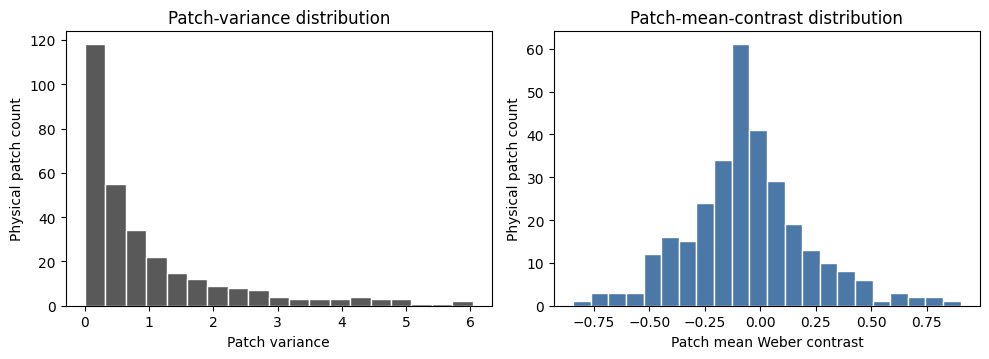

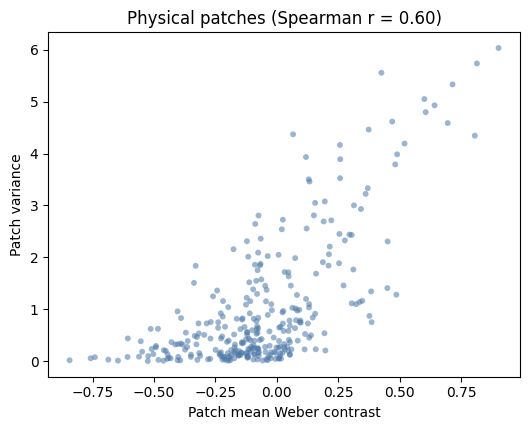

,binning,min_patches,max_patches,empty_cells,count_cv
0,Equal numeric intervals,0,121,17,2.539436
1,Shared marginal quantiles,0,35,3,0.753134
2,Nested adaptive quantiles,8,9,0,0.058541


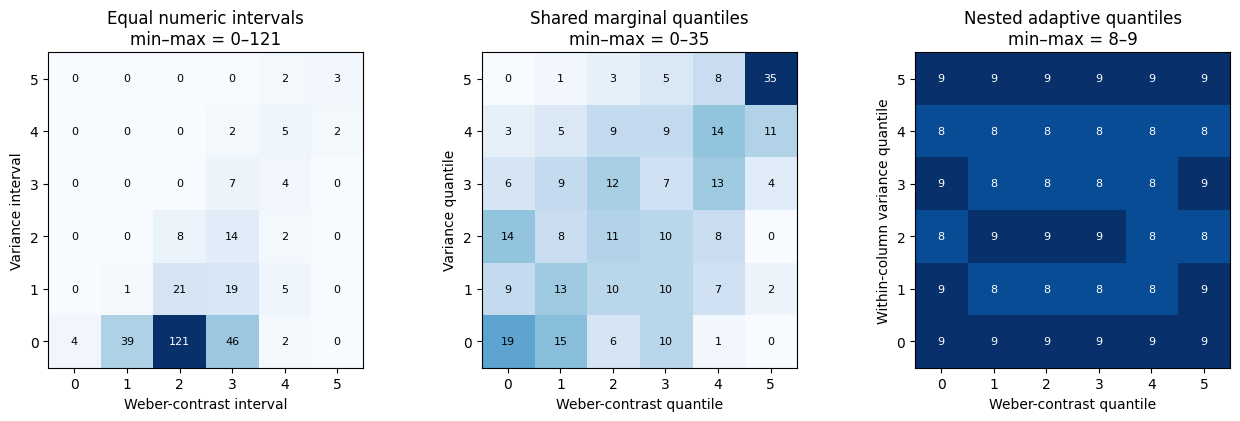

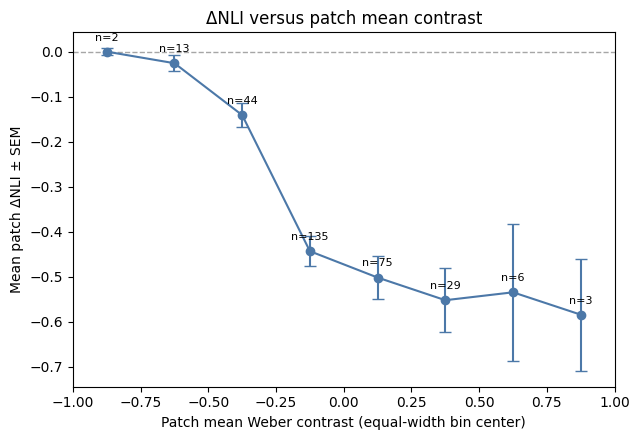

,contrast_bin,mean_contrast,mean_delta_nli,sem_delta_nli,n_patches,bin_left,bin_right,bin_center
0,0,-0.801080,0.000190,0.007158,2,-1.00,-0.75,-0.875
1,1,-0.579063,-0.025496,0.018080,13,-0.75,-0.50,-0.625
2,2,-0.373733,-0.140847,0.026099,44,-0.50,-0.25,-0.375
3,3,-0.119751,-0.443231,0.033617,135,-0.25,0.00,-0.125
4,4,0.085434,-0.501807,0.048001,75,0.00,0.25,0.125
5,5,0.352594,-0.552133,0.070826,29,0.25,0.50,0.375
6,6,0.630324,-0.534578,0.151740,6,0.50,0.75,0.625
7,7,0.841523,-0.584305,0.124307,3,0.75,1.00,0.875


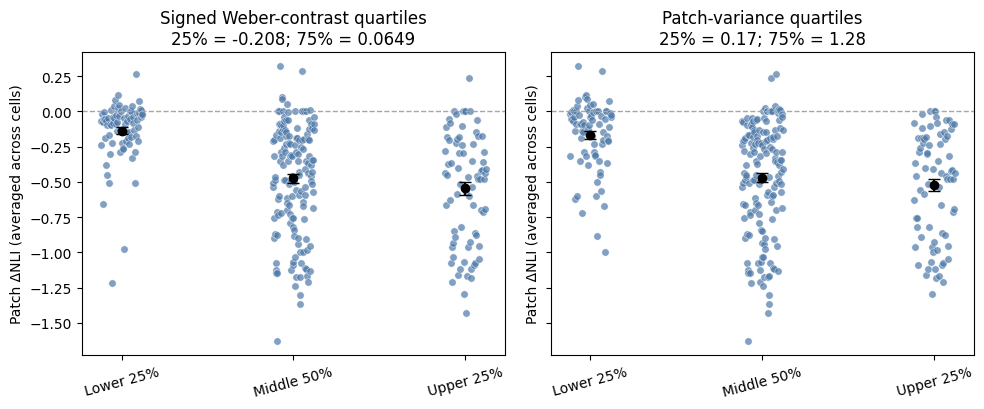

,split_variable,lower_25_cutoff,upper_75_cutoff,group,n_patches,mean_delta_nli,sem_delta_nli
0,patchMeanContrast,-0.208018,0.064863,Lower 25%,77,-0.136129,0.024796
1,patchMeanContrast,-0.208018,0.064863,Middle 50%,153,-0.473708,0.031543
2,patchMeanContrast,-0.208018,0.064863,Upper 25%,77,-0.545623,0.045047
3,patchVariance,0.170210,1.277921,Lower 25%,77,-0.164522,0.027959
4,patchVariance,0.170210,1.277921,Middle 50%,153,-0.470748,0.032427
5,patchVariance,0.170210,1.277921,Upper 25%,77,-0.523112,0.043761


In [2]:
import matplotlib.pyplot as plt
from IPython.display import display

HIGH_LIGHT_MIN_RSTAR = 4000.0
ANALYSIS_CELL_TYPE = 'OFF-parasol'
ANALYSIS_RECORDING_MODES = 'extracellular'  # string or tuple both work
WEBER_CONTRAST_RANGE = (-1.0, 1.0)
GRID_BINS = 6
CONTRAST_SUMMARY_BINS = 8

# This also permits Section 3e to run after imports without rebuilding Section 3d.
if 'patch_variance_population' not in globals():
    patch_variance_population = led.load_patch_variance_population()

analysis_columns = [
    'meanIntensity_Rstar_per_s', 'patchMeanContrast', 'patchVariance',
    'delta_nli_cone_minus_disc']
high_light = patch_variance_population.copy()
for column in analysis_columns:
    high_light[column] = pd.to_numeric(high_light[column], errors='coerce')
cell_type_mask = (high_light['cell_type'].astype(str).str.casefold()
                  == str(ANALYSIS_CELL_TYPE).casefold())
analysis_modes = ((ANALYSIS_RECORDING_MODES,)
                  if isinstance(ANALYSIS_RECORDING_MODES, str)
                  else tuple(ANALYSIS_RECORDING_MODES))
mode_mask = high_light['onlineAnalysis'].astype(str).str.casefold().isin(
    [str(mode).casefold() for mode in analysis_modes])
finite_mask = np.isfinite(high_light[analysis_columns]).all(axis=1)
light_mask = high_light['meanIntensity_Rstar_per_s'] >= HIGH_LIGHT_MIN_RSTAR
weber_mask = high_light['patchMeanContrast'].between(
    WEBER_CONTRAST_RANGE[0], WEBER_CONTRAST_RANGE[1], inclusive='both')
print('Filter audit: '
      f'all={len(high_light)}, cell type={int(cell_type_mask.sum())}, '
      f'mode {analysis_modes}={int((cell_type_mask & mode_mask).sum())}, '
      f'+ light={int((cell_type_mask & mode_mask & light_mask).sum())}, '
      f'+ Weber/finite='
      f'{int((cell_type_mask & mode_mask & light_mask & weber_mask & finite_mask).sum())}')
high_light = high_light.loc[
    cell_type_mask & mode_mask & light_mask & weber_mask & finite_mask].copy()
if high_light.empty:
    raise ValueError(
        f'No rows remain for cell_type={ANALYSIS_CELL_TYPE!r}, '
        f'modes={analysis_modes}, light≥{HIGH_LIGHT_MIN_RSTAR:g}, '
        f'Weber={WEBER_CONTRAST_RANGE}. Check the filter audit above.')
high_light['cell_id'] = (
    high_light['date'].astype(str) + '/' + high_light['cell_label'].astype(str))

# One plotted observation per physical patch. Collapse repeated conditions
# within a cell first, then weight each contributing cell equally.
cell_patch_values = (high_light.groupby(['cell_id', 'patch_uid'], as_index=False)
                     .agg(imageName=('imageName', 'first'),
                          patch_x_vh=('patch_x_vh', 'first'),
                          patch_y_vh=('patch_y_vh', 'first'),
                          patchMeanContrast=('patchMeanContrast', 'mean'),
                          patchVariance=('patchVariance', 'mean'),
                          delta_nli_cone_minus_disc=(
                              'delta_nli_cone_minus_disc', 'mean'),
                          n_source_rows=('patch_uid', 'size')))
physical_patches = (cell_patch_values.groupby('patch_uid', as_index=False)
                    .agg(imageName=('imageName', 'first'),
                         patch_x_vh=('patch_x_vh', 'first'),
                         patch_y_vh=('patch_y_vh', 'first'),
                         patchMeanContrast=('patchMeanContrast', 'mean'),
                         patchVariance=('patchVariance', 'mean'),
                         delta_nli_cone_minus_disc=(
                             'delta_nli_cone_minus_disc', 'mean'),
                         n_cells=('cell_id', 'size'),
                         n_observations=('n_source_rows', 'sum')))
print(f'High-light selection: {len(high_light)} rows, '
      f'{high_light.cell_id.nunique()} cells, '
      f'{physical_patches.patch_uid.nunique()} physical patches; '
      f'{ANALYSIS_CELL_TYPE}, {analysis_modes}, '
      f'mean light ≥ {HIGH_LIGHT_MIN_RSTAR:g} R*/s, '
      f'Weber contrast {WEBER_CONTRAST_RANGE}')

# 1–2. Marginal stimulus-property distributions.
fig, axes = plt.subplots(1, 2, figsize=(10, 3.7))
axes[0].hist(physical_patches['patchVariance'], bins='auto',
             color='0.35', edgecolor='white')
axes[0].set(xlabel='Patch variance', ylabel='Physical patch count',
            title='Patch-variance distribution')
axes[1].hist(physical_patches['patchMeanContrast'], bins='auto',
             color='#4C78A8', edgecolor='white')
axes[1].set(xlabel='Patch mean Weber contrast', ylabel='Physical patch count',
            title='Patch-mean-contrast distribution')
fig.tight_layout()
plt.show()

# 3. Joint stimulus-property distribution.
fig, ax = plt.subplots(figsize=(5.4, 4.4))
ax.scatter(physical_patches['patchMeanContrast'],
           physical_patches['patchVariance'], s=18, alpha=0.55,
           color='#4C78A8', edgecolors='none')
spearman_r = physical_patches[['patchMeanContrast', 'patchVariance']].corr(
    method='spearman').iloc[0, 1]
ax.set(xlabel='Patch mean Weber contrast', ylabel='Patch variance',
       title=f'Physical patches (Spearman r = {spearman_r:.2f})')
fig.tight_layout()
plt.show()

# 4a. Compare unique-patch occupancy under three 2-D binning schemes.
def _quantile_edges(values, n_bins):
    edges = np.unique(np.quantile(values, np.linspace(0, 1, n_bins + 1)))
    if len(edges) != n_bins + 1:
        raise ValueError(
            f'Only {len(edges) - 1} distinct quantile bins are available')
    return edges

contrast = physical_patches['patchMeanContrast']
variance = physical_patches['patchVariance']
even_x_edges = np.linspace(
    WEBER_CONTRAST_RANGE[0], WEBER_CONTRAST_RANGE[1], GRID_BINS + 1)
even_y_edges = np.linspace(variance.min(), variance.max(), GRID_BINS + 1)
even_counts = np.histogram2d(
    variance, contrast, bins=[even_y_edges, even_x_edges])[0].astype(int)
quantile_x_edges = _quantile_edges(contrast, GRID_BINS)
quantile_y_edges = _quantile_edges(variance, GRID_BINS)
marginal_counts = np.histogram2d(
    variance, contrast, bins=[quantile_y_edges, quantile_x_edges])[0].astype(int)

# Equal-count contrast columns, then equal-count variance rows separately
# inside each column. This balances cells but does not share y boundaries.
nested_counts = np.zeros((GRID_BINS, GRID_BINS), dtype=int)
nested_x = pd.qcut(contrast.rank(method='first'), GRID_BINS, labels=False)
for xi in range(GRID_BINS):
    in_column = nested_x == xi
    nested_y = pd.qcut(
        variance.loc[in_column].rank(method='first'),
        GRID_BINS, labels=False)
    for yi in range(GRID_BINS):
        nested_counts[yi, xi] = int((nested_y == yi).sum())

def _occupancy_stats(label, counts):
    return {
        'binning': label, 'min_patches': int(counts.min()),
        'max_patches': int(counts.max()),
        'empty_cells': int((counts == 0).sum()),
        'count_cv': float(counts.std() / counts.mean())}

occupancy_summary = pd.DataFrame([
    _occupancy_stats('Equal numeric intervals', even_counts),
    _occupancy_stats('Shared marginal quantiles', marginal_counts),
    _occupancy_stats('Nested adaptive quantiles', nested_counts),
])
display(occupancy_summary)

def _plot_count_grid(ax, counts, title, xlabel, ylabel):
    image = ax.imshow(counts, origin='lower', cmap='Blues', aspect='equal',
                      vmin=0, vmax=max(1, counts.max()))
    threshold = counts.max() * 0.55
    for yi in range(counts.shape[0]):
        for xi in range(counts.shape[1]):
            ax.text(xi, yi, str(counts[yi, xi]), ha='center', va='center',
                    fontsize=8, color='white' if counts[yi, xi] > threshold else 'black')
    ax.set(title=f'{title}\nmin–max = {counts.min()}–{counts.max()}',
           xlabel=xlabel, ylabel=ylabel,
           xticks=range(GRID_BINS), yticks=range(GRID_BINS))
    return image

fig, axes = plt.subplots(1, 3, figsize=(13, 4.1), constrained_layout=True)
_plot_count_grid(
    axes[0], even_counts, 'Equal numeric intervals',
    'Weber-contrast interval', 'Variance interval')
_plot_count_grid(
    axes[1], marginal_counts, 'Shared marginal quantiles',
    'Weber-contrast quantile', 'Variance quantile')
_plot_count_grid(
    axes[2], nested_counts, 'Nested adaptive quantiles',
    'Weber-contrast quantile', 'Within-column variance quantile')
plt.show()

# 4b. ΔNLI mean ± SEM in evenly spaced signed Weber-contrast bins.
contrast_edges = np.linspace(
    WEBER_CONTRAST_RANGE[0], WEBER_CONTRAST_RANGE[1],
    CONTRAST_SUMMARY_BINS + 1)
contrast_bin = pd.cut(
    contrast, contrast_edges, include_lowest=True, labels=False)
contrast_bin_summary = (physical_patches.assign(contrast_bin=contrast_bin)
                    .groupby('contrast_bin', as_index=False, observed=False)
                    .agg(mean_contrast=('patchMeanContrast', 'mean'),
                         mean_delta_nli=('delta_nli_cone_minus_disc', 'mean'),
                         sem_delta_nli=('delta_nli_cone_minus_disc', 'sem'),
                         n_patches=('patch_uid', 'size')))
all_bins = pd.DataFrame({'contrast_bin': range(CONTRAST_SUMMARY_BINS)})
contrast_bin_summary = all_bins.merge(
    contrast_bin_summary, on='contrast_bin', how='left')
contrast_bin_summary['bin_left'] = contrast_edges[:-1]
contrast_bin_summary['bin_right'] = contrast_edges[1:]
contrast_bin_summary['bin_center'] = (
    contrast_bin_summary['bin_left'] + contrast_bin_summary['bin_right']) / 2

fig, ax = plt.subplots(figsize=(6.5, 4.5))
valid = contrast_bin_summary['n_patches'].fillna(0) > 0
ax.errorbar(
    contrast_bin_summary.loc[valid, 'bin_center'],
    contrast_bin_summary.loc[valid, 'mean_delta_nli'],
    yerr=contrast_bin_summary.loc[valid, 'sem_delta_nli'],
    fmt='o-', color='#4C78A8', capsize=4, linewidth=1.5)
for row in contrast_bin_summary.loc[valid].itertuples():
    ax.annotate(f'n={int(row.n_patches)}',
                (row.bin_center, row.mean_delta_nli),
                xytext=(0, 8), textcoords='offset points',
                ha='center', fontsize=8)
ax.axhline(0, color='0.65', linewidth=1, linestyle='--')
ax.set(xlim=WEBER_CONTRAST_RANGE,
       xlabel='Patch mean Weber contrast (equal-width bin center)',
       ylabel='Mean patch ΔNLI ± SEM',
       title='ΔNLI versus patch mean contrast')
fig.tight_layout()
plt.show()
display(contrast_bin_summary)

# 5–6. Quartile groups with unique patches as points and mean ± SEM.
def _plot_patch_group_comparison(ax, table, split_column, title):
    lower_cutoff, upper_cutoff = table[split_column].quantile([0.25, 0.75])
    labels = ('Lower 25%', 'Middle 50%', 'Upper 25%')
    grouped = table.copy()
    grouped['group'] = np.select(
        [grouped[split_column] <= lower_cutoff,
         grouped[split_column] >= upper_cutoff],
        [labels[0], labels[2]], default=labels[1])
    summary_rows = []
    for xpos, label in enumerate(labels):
        values = grouped.loc[
            grouped['group'] == label, 'delta_nli_cone_minus_disc']
        offsets = np.linspace(-0.12, 0.12, len(values)) if len(values) > 1 else [0]
        ax.scatter(xpos + np.asarray(offsets), values, s=28, alpha=0.7,
                   color='#4C78A8', edgecolors='white', linewidths=0.4)
        mean = values.mean()
        sem = values.sem() if len(values) > 1 else np.nan
        ax.errorbar(xpos, mean, yerr=sem, fmt='o', color='black',
                    capsize=4, markersize=6, linewidth=1.5, zorder=5)
        summary_rows.append({
            'split_variable': split_column,
            'lower_25_cutoff': lower_cutoff,
            'upper_75_cutoff': upper_cutoff,
            'group': label, 'n_patches': len(values),
            'mean_delta_nli': mean, 'sem_delta_nli': sem})
    ax.axhline(0, color='0.65', linewidth=1, linestyle='--')
    ax.set(xticks=range(len(labels)), xticklabels=labels,
           ylabel='Patch ΔNLI (averaged across cells)',
           title=f'{title}\n25% = {lower_cutoff:.3g}; 75% = {upper_cutoff:.3g}')
    ax.tick_params(axis='x', rotation=15)
    return pd.DataFrame(summary_rows)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), sharey=True)
contrast_summary = _plot_patch_group_comparison(
    axes[0], physical_patches, 'patchMeanContrast',
    'Signed Weber-contrast quartiles')
variance_summary = _plot_patch_group_comparison(
    axes[1], physical_patches, 'patchVariance',
    'Patch-variance quartiles')
fig.tight_layout()
plt.show()
group_summary = pd.concat([contrast_summary, variance_summary], ignore_index=True)
group_summary

### 4a. Preview recorded stimuli

This optional visualization uses the date already loaded in Section 2. The dropdown contains
every recorded `imageName` for that date; choosing one redraws several recorded patches as a
tilted flash sequence. Each triplet proceeds from natural-image patch to linear-equivalent disc
to cone-linearized disc, and the diagonal time arrow shows the repeated presentation order.
Spatial x/y arrows follow the tilted edges of the first stimulus plane. As in the original
center-disc protocol, the full canvas stays at the recorded `backgroundIntensity`; only the
circular `apertureDiameter` region changes among the three stimulus classes. All stimuli use a
common grey scale. The image is loaded from the van Hateren resources in the turner package as
`NaturalImageFlashProtocol.m` does.

A useful geometry check: the mean intensity inside the center aperture should match the
recorded `equivalentIntensity`.

In [4]:
image_example = led.stimulus_example_widget(selected_blocks, sequence_length=4)
image_example

## 5. Rig maxIntensity and NDF configuration check

This metadata-only QC reverses both attenuation sources: `estimated rig maxIntensity = recorded maxIntensity × 10**(manual NDF OD + FilterWheel OD)`. Manual Stage labels carry their nominal OD (`EL3 = 3.0`; `EL06 + EL2 = 2.6`), while the numeric FilterWheel value is authoritative and embedded `FW...` labels are shown but not counted twice. The summary reports the median and full observed range; the evidence table retains every manual/filter-wheel combination so calibration changes or bad entries remain visible. No traces or response analysis are loaded.

In [2]:
rig_max_map, rig_ndf_evidence = led.estimate_rig_max_intensity(
    protocols=('LinearEquivalentDiscConeLin', 'LinearEquivalentDisc'))

Formula: recorded maxIntensity × 10^(manual NDF OD + FilterWheel OD)
ALERT: 27 block(s) could not be estimated because manual NDF, wheel NDF, or maxIntensity was unavailable.
ALERT: rig G, EL06, EL2, FW0 spans 3.06543e+06–3.08533e+07; check its blocks.

Rig maxIntensity map (median with full observed range):


rig,data_source,estimated_rig_maxIntensity,estimate_min,estimate_max,manual_ndfs,filter_wheel_ndfs,blocks,experiment_dates
E,fred_data,30000000.0,25000000.0,60000000.0,EL3,"0, 0.5, 1, 3, 4",165,17
G,chris_data,30256144.962065797,3065425.2132619293,123706263.5280705,"EL03, EL2 | EL06, EL2 | EL2","0, 0.5, 1",115,9



Evidence by manual-NDF and FilterWheel combination:


rig,data_source,manual_ndfs,manual_ndf_od,filter_wheel_ndf,recorded_maxIntensity,estimated_rig_maxIntensity,estimate_min,estimate_max,blocks,experiment_dates,status
E,fred_data,(not recorded),,0.0,30000,,,,17,2,manual NDF not recorded
E,fred_data,EL3,3.0,0.0,"25000, 30000",30000000.0,25000000.0,30000000.0,103,16,
E,fred_data,EL3,3.0,0.5,10000,31622776.601683795,31622776.601683795,31622776.601683795,4,1,
E,fred_data,EL3,3.0,1.0,3000,30000000.0,30000000.0,30000000.0,21,5,
E,fred_data,EL3,3.0,3.0,60,60000000.0,60000000.0,60000000.0,32,2,
E,fred_data,EL3,3.0,4.0,6,60000000.0,60000000.0,60000000.0,5,2,
E,fred_data,EL3,3.0,,"3000, 30000",,,,10,1,
G,chris_data,"EL03, EL2",2.3,0.0,"61000, 61500, 62000",12370626.352807049,12171100.12131016,12370626.352807049,13,2,
G,chris_data,"EL03, EL2",2.3,1.0,62000,123706263.5280705,123706263.5280705,123706263.5280705,1,1,
G,chris_data,"EL06, EL2",2.6,0.0,"7700, 76000, 77000, 77500",30654252.132619295,3065425.2132619293,30853305.717896044,51,5,inconsistent estimates (>25% spread)
